# Train YOLO on CrowdHuman + MOT17 (Person Detection, target mAP50 ≥ 85%)

This notebook:
1. Installs dependencies (`ultralytics`, `huggingface_hub`, etc.)
2. Downloads **CrowdHuman** (train + val, from the official Hugging Face mirror) and **MOT17** (from motchallenge.net)
3. Converts both datasets' annotations into YOLO `.txt` format, single class **`person`**
   - CrowdHuman: uses the **full-body box** (`hbox`) of every `person`-tagged instance
   - MOT17: uses `gt/gt.txt`, keeping only pedestrian boxes (`class == 1`, `conf == 1`)
4. Merges everything into one YOLO dataset folder + `data.yaml`
5. Trains a YOLO model (`yolo26m.pt` by default) for **50 epochs**, then automatically keeps fine-tuning in extra rounds if validation `mAP50` hasn't hit the target yet (capped at `MAX_TOTAL_EPOCHS`)
6. Validates and exports the trained model

> **Before you run this:** CrowdHuman is ~15 GB zipped, MOT17 is ~5 GB zipped. Make sure you have **≥60 GB free disk** (raw zips + extracted images + YOLO copies) and a CUDA GPU. If you just want to sanity-check the pipeline first, set `QUICK_TEST = True` in the config cell to only process a small subset of images before committing to a full run.


## 0. Install dependencies

In [1]:
%pip install -q -U ultralytics huggingface_hub kagglehub requests tqdm pyyaml opencv-python-headless matplotlib


Note: you may need to restart the kernel to use updated packages.


## 1. Configuration

In [2]:
import os
from pathlib import Path

# ----------------------------------------------------------------
# General config
# ----------------------------------------------------------------

ROOT = Path("./yolo_head_project").resolve()

RAW_DIR = ROOT / "raw"
DATASET_DIR = ROOT / "head_dataset"
RUNS_DIR = ROOT / "runs"

for d in [ROOT, RAW_DIR, DATASET_DIR, RUNS_DIR]:
    d.mkdir(parents=True, exist_ok=True)


# ----------------------------------------------------------------
# Model / training config
# ----------------------------------------------------------------

MODEL_NAME = "yolo26n.pt"

EPOCHS = 50
TARGET_MAP50 = 0.85
MAX_TOTAL_EPOCHS = 150
EXTRA_EPOCHS_PER_ROUND = 30

# Heads are smaller than full bodies.
# Start with 1280 if your GPU can handle it.
IMG_SIZE = 1280

DEVICE = 0
BATCH = 16
WORKERS = 8

RUN_NAME = "head_crowdhuman"


# ----------------------------------------------------------------
# Quick test
# ----------------------------------------------------------------

QUICK_TEST = False
QUICK_TEST_IMAGES_PER_SOURCE = 200


print(f"Project root: {ROOT}")
print(f"Model: {MODEL_NAME} | epochs: {EPOCHS} | imgsz: {IMG_SIZE} | batch: {BATCH}")

Project root: /home/student-12/Desktop/crowddt/models/crowdhumanhbox/yolo_head_project
Model: yolo26n.pt | epochs: 50 | imgsz: 1280 | batch: 16


## 2. Download CrowdHuman

Official site (`crowdhuman.org`) links are Google-Drive hosted and unreliable to script against, so we pull the dataset from the Hugging Face mirror `sshao0516/CrowdHuman`, which hosts the same official zips + `.odgt` annotation files.

In [3]:
from huggingface_hub import hf_hub_download
import zipfile

CROWDHUMAN_DIR = RAW_DIR / "crowdhuman"
CROWDHUMAN_DIR.mkdir(parents=True, exist_ok=True)

HF_REPO = "sshao0516/CrowdHuman"

CROWDHUMAN_FILES = [
    "CrowdHuman_train01.zip",
    "CrowdHuman_train02.zip",
    "CrowdHuman_train03.zip",
    "CrowdHuman_val.zip",
    "annotation_train.odgt",
    "annotation_val.odgt",
]

def download_crowdhuman():
    for fname in CROWDHUMAN_FILES:
        dest = CROWDHUMAN_DIR / fname
        if dest.exists():
            print(f"[skip] {fname} already downloaded")
            continue
        print(f"[download] {fname} ...")
        path = hf_hub_download(repo_id=HF_REPO, repo_type="dataset", filename=fname,
                                local_dir=CROWDHUMAN_DIR)
        print(f"  -> saved to {path}")

download_crowdhuman()


[skip] CrowdHuman_train01.zip already downloaded
[skip] CrowdHuman_train02.zip already downloaded
[skip] CrowdHuman_train03.zip already downloaded
[skip] CrowdHuman_val.zip already downloaded
[skip] annotation_train.odgt already downloaded
[skip] annotation_val.odgt already downloaded


In [4]:
# Extract CrowdHuman images (all train zips + val zip land in one flat "Images" dir)
CROWDHUMAN_IMG_DIR = CROWDHUMAN_DIR / "Images"
CROWDHUMAN_IMG_DIR.mkdir(parents=True, exist_ok=True)

def extract_zip(zip_path, out_dir):
    marker = out_dir / f".{zip_path.stem}_extracted"
    if marker.exists():
        print(f"[skip] {zip_path.name} already extracted")
        return
    print(f"[extract] {zip_path.name} -> {out_dir}")
    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(out_dir)
    marker.touch()

for zname in ["CrowdHuman_train01.zip", "CrowdHuman_train02.zip", "CrowdHuman_train03.zip", "CrowdHuman_val.zip"]:
    zpath = CROWDHUMAN_DIR / zname
    extract_zip(zpath, CROWDHUMAN_IMG_DIR)

# Some releases extract into an "Images/Images" subfolder - flatten if needed
nested = CROWDHUMAN_IMG_DIR / "Images"
if nested.exists():
    for f in nested.iterdir():
        f.rename(CROWDHUMAN_IMG_DIR / f.name)
    nested.rmdir()

n_images = len(list(CROWDHUMAN_IMG_DIR.glob("*.jpg")))
print(f"CrowdHuman images extracted: {n_images}")


[skip] CrowdHuman_train01.zip already extracted
[skip] CrowdHuman_train02.zip already extracted
[skip] CrowdHuman_train03.zip already extracted
[skip] CrowdHuman_val.zip already extracted
CrowdHuman images extracted: 19370


## 3. Convert CrowdHuman HBOX annotations -> YOLO format

Each line of `annotation_*.odgt` is a JSON object with a `gtboxes` list.

We keep boxes tagged `"person"` and use the **head bounding box**
(`hbox`, format `[x, y, w, h]` in pixels).

The head boxes are converted to normalized YOLO
`class x_center y_center width height` format.

Class id `0` represents `head`.

In [5]:
import json
import cv2
from tqdm.auto import tqdm

CLASS_ID_HEAD = 0


def convert_crowdhuman_heads(
    odgt_path,
    images_dir,
    out_img_dir,
    out_lbl_dir,
    limit=None
):
    out_img_dir.mkdir(parents=True, exist_ok=True)
    out_lbl_dir.mkdir(parents=True, exist_ok=True)

    with open(odgt_path, "r") as f:
        lines = f.readlines()

    if limit:
        lines = lines[:limit]

    n_ok = 0
    n_missing = 0

    for line in tqdm(
        lines,
        desc=f"CrowdHuman HBOX: {odgt_path.name}"
    ):

        record = json.loads(line)

        img_id = record["ID"]

        src_img = images_dir / f"{img_id}.jpg"

        if not src_img.exists():
            n_missing += 1
            continue

        img = cv2.imread(str(src_img))

        if img is None:
            n_missing += 1
            continue

        h, w = img.shape[:2]

        yolo_lines = []

        for box in record.get("gtboxes", []):

            # Only actual people
            if box.get("tag") != "person":
                continue

            # Skip ignored annotations
            extra = box.get("extra", {})

            if extra.get("ignore", 0) == 1:
                continue

            # ------------------------------------------------
            # IMPORTANT:
            # FBOX version used box["fbox"]
            #
            # HBOX version uses box["hbox"]
            # ------------------------------------------------

            if "hbox" not in box:
                continue

            x, y, bw, bh = box["hbox"]

            # Clip to image boundaries
            x = max(0, x)
            y = max(0, y)

            bw = min(bw, w - x)
            bh = min(bh, h - y)

            if bw <= 1 or bh <= 1:
                continue

            # Convert pixel coordinates → YOLO normalized format

            xc = (x + bw / 2) / w
            yc = (y + bh / 2) / h

            nw = bw / w
            nh = bh / h

            yolo_lines.append(
                f"{CLASS_ID_HEAD} "
                f"{xc:.6f} "
                f"{yc:.6f} "
                f"{nw:.6f} "
                f"{nh:.6f}"
            )

        # No valid heads
        if not yolo_lines:
            continue

        # ------------------------------------------------
        # Link/copy image
        # ------------------------------------------------

        dst_img = out_img_dir / src_img.name

        if not dst_img.exists():

            try:
                os.symlink(src_img, dst_img)

            except OSError:
                import shutil
                shutil.copy(src_img, dst_img)

        # ------------------------------------------------
        # Write YOLO label
        # ------------------------------------------------

        label_path = out_lbl_dir / f"{img_id}.txt"

        label_path.write_text(
            "\n".join(yolo_lines)
        )

        n_ok += 1

    print(
        f"  -> {n_ok} images converted, "
        f"{n_missing} missing/unreadable"
    )


# ------------------------------------------------
# Convert train + validation
# ------------------------------------------------

ch_limit = (
    QUICK_TEST_IMAGES_PER_SOURCE
    if QUICK_TEST
    else None
)


convert_crowdhuman_heads(
    CROWDHUMAN_DIR / "annotation_train.odgt",
    CROWDHUMAN_IMG_DIR,

    DATASET_DIR / "images" / "train",
    DATASET_DIR / "labels" / "train",

    limit=ch_limit,
)


convert_crowdhuman_heads(
    CROWDHUMAN_DIR / "annotation_val.odgt",
    CROWDHUMAN_IMG_DIR,

    DATASET_DIR / "images" / "val",
    DATASET_DIR / "labels" / "val",

    limit=ch_limit,
)

CrowdHuman HBOX: annotation_train.odgt:   0%|          | 0/15000 [00:00<?, ?it/s]

  -> 15000 images converted, 0 missing/unreadable


CrowdHuman HBOX: annotation_val.odgt:   0%|          | 0/4370 [00:00<?, ?it/s]

  -> 4370 images converted, 0 missing/unreadable


## 3. Write `data.yaml` and sanity-check counts

In [6]:
import yaml

data_yaml = {
    "path": str(DATASET_DIR),
    "train": "images/train",
    "val": "images/val",
    "names": {
        0: "head"
    },
}

data_yaml_path = DATASET_DIR / "data.yaml"

with open(data_yaml_path, "w") as f:
    yaml.dump(
        data_yaml,
        f,
        sort_keys=False
    )


for split in ["train", "val"]:

    n_img = len(
        list(
            (DATASET_DIR / "images" / split).glob("*.jpg")
        )
    )

    n_lbl = len(
        list(
            (DATASET_DIR / "labels" / split).glob("*.txt")
        )
    )

    print(
        f"{split}: "
        f"{n_img} images, "
        f"{n_lbl} label files"
    )


print(
    f"\ndata.yaml written to: "
    f"{data_yaml_path}"
)

print(data_yaml_path.read_text())

train: 15000 images, 15000 label files
val: 4370 images, 4370 label files

data.yaml written to: /home/student-12/Desktop/crowddt/models/crowdhumanhbox/yolo_head_project/head_dataset/data.yaml
path: /home/student-12/Desktop/crowddt/models/crowdhumanhbox/yolo_head_project/head_dataset
train: images/train
val: images/val
names:
  0: head



## 4. Visual sanity check (optional but recommended)

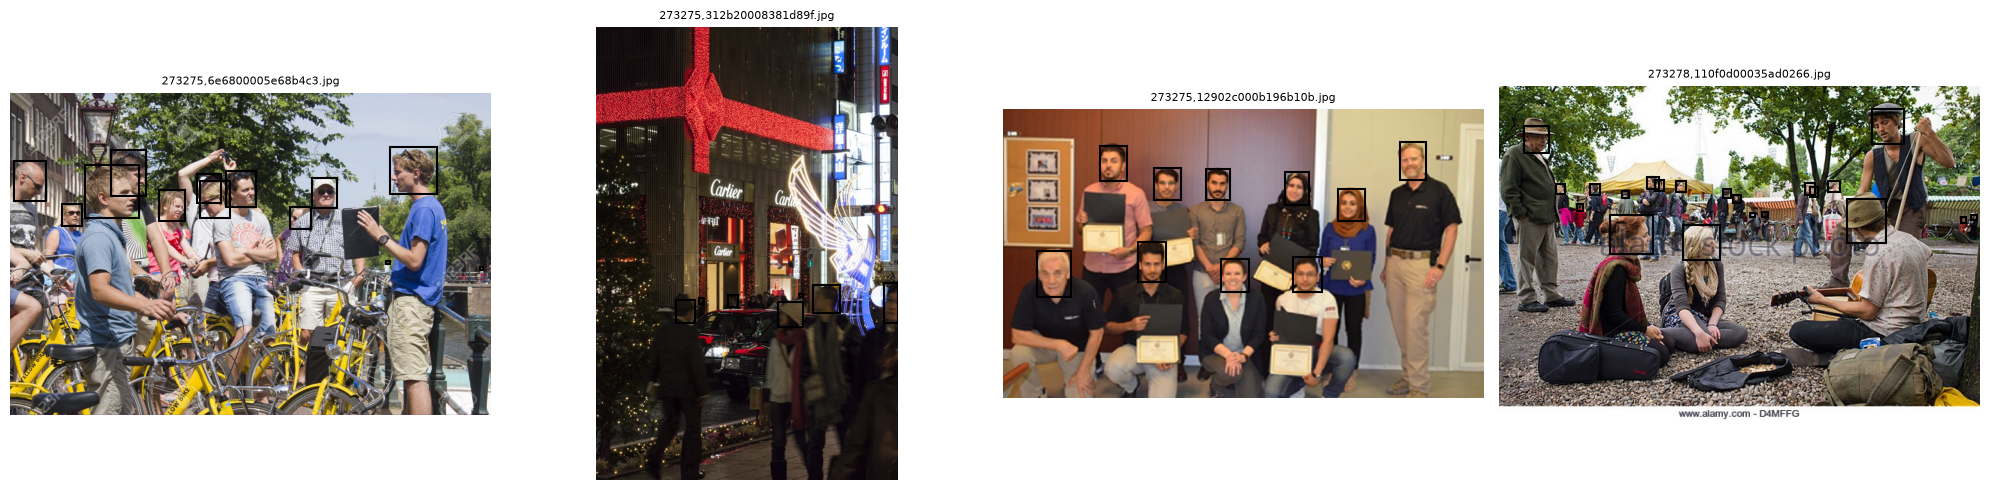

In [7]:
import random
import matplotlib.pyplot as plt


def show_head_sample(split="train", n=4):

    img_dir = DATASET_DIR / "images" / split
    lbl_dir = DATASET_DIR / "labels" / split

    imgs = random.sample(
        list(img_dir.glob("*.jpg")),
        k=min(
            n,
            len(list(img_dir.glob("*.jpg")))
        )
    )

    fig, axes = plt.subplots(
        1,
        len(imgs),
        figsize=(5 * len(imgs), 5)
    )

    if len(imgs) == 1:
        axes = [axes]

    for ax, img_path in zip(axes, imgs):

        img = cv2.cvtColor(
            cv2.imread(str(img_path)),
            cv2.COLOR_BGR2RGB
        )

        h, w = img.shape[:2]

        ax.imshow(img)

        lbl_path = (
            lbl_dir /
            f"{img_path.stem}.txt"
        )

        if lbl_path.exists():

            for line in lbl_path.read_text().splitlines():

                _, xc, yc, nw, nh = map(
                    float,
                    line.split()
                )

                x1 = (xc - nw / 2) * w
                y1 = (yc - nh / 2) * h

                ax.add_patch(
                    plt.Rectangle(
                        (x1, y1),
                        nw * w,
                        nh * h,
                        fill=False,
                        linewidth=1.5
                    )
                )

        ax.set_title(
            img_path.name,
            fontsize=8
        )

        ax.axis("off")

    plt.tight_layout()
    plt.show()


show_head_sample("train", n=4)

## 5. Train YOLO, auto-extending until it hits the accuracy target

Trains for `EPOCHS` first, checks val `mAP50` against `TARGET_MAP50`, and if it's not there yet, keeps fine-tuning from the best checkpoint in additional `EXTRA_EPOCHS_PER_ROUND`-epoch rounds (up to `MAX_TOTAL_EPOCHS` total) rather than silently stopping short of the goal.

In [ ]:
from ultralytics import YOLO


def train_round(
    model_path,
    epochs,
    run_name
):

    m = YOLO(model_path)

    m.train(

        data=str(data_yaml_path),

        epochs=epochs,

        imgsz=IMG_SIZE,

        batch=BATCH,

        device=DEVICE,

        workers=WORKERS,

        project=str(RUNS_DIR),

        name=run_name,

        patience=0,

        exist_ok=True,

        optimizer="AdamW",

        cos_lr=True,

        mosaic=1.0,

        close_mosaic=10,

        scale=0.5,

        mixup=0.1,

        copy_paste=0.3,

        fliplr=0.5,

        hsv_h=0.015,
        hsv_s=0.5,
        hsv_v=0.3,
    )

    weights = (
        RUNS_DIR /
        run_name /
        "weights" /
        "best.pt"
    )

    metrics = YOLO(weights).val(
        data=str(data_yaml_path),
        imgsz=IMG_SIZE,
        device=DEVICE,
        augment=True
    )

    return (
        weights,
        float(metrics.box.map50)
    )


# ------------------------------------------------
# Initial training
# ------------------------------------------------

round_num = 1

total_epochs = EPOCHS

run_name = RUN_NAME


best_weights, map50 = train_round(
    MODEL_NAME,
    EPOCHS,
    run_name
)


print(
    f"[round {round_num}] "
    f"total_epochs={total_epochs} "
    f"mAP50={map50:.3f} "
    f"(target {TARGET_MAP50:.2f})"
)


# ------------------------------------------------
# Automatically extend training
# ------------------------------------------------

while (
    map50 < TARGET_MAP50
    and total_epochs < MAX_TOTAL_EPOCHS
):

    round_num += 1

    run_name = (
        f"{RUN_NAME}_r{round_num}"
    )

    next_epochs = min(
        EXTRA_EPOCHS_PER_ROUND,
        MAX_TOTAL_EPOCHS - total_epochs
    )

    best_weights, map50 = train_round(
        best_weights,
        next_epochs,
        run_name
    )

    total_epochs += next_epochs

    print(
        f"[round {round_num}] "
        f"total_epochs={total_epochs} "
        f"mAP50={map50:.3f} "
        f"(target {TARGET_MAP50:.2f})"
    )


if map50 >= TARGET_MAP50:

    print(
        f"\nTarget reached: "
        f"mAP50={map50:.3f} "
        f"after {total_epochs} total epochs."
    )

else:

    print(
        f"\nHit MAX_TOTAL_EPOCHS "
        f"({MAX_TOTAL_EPOCHS}) before reaching target. "
        f"Best so far: mAP50={map50:.3f}."
    )


print(f"Final weights: {best_weights}")

Ultralytics 8.4.137 🚀 Python-3.12.3 torch-2.13.0+cu130 CUDA:0 (NVIDIA GB10, 122508MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/home/student-12/Desktop/crowddt/models/crowdhumanhbox/yolo_head_project/head_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.5, hsv_v=0.3, imgsz=1280, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo26n.pt, momentum=0.937

## 6. Final HBOX validation report

In [ ]:
trained_model = YOLO(best_weights)

metrics = trained_model.val(
    data=str(data_yaml_path),
    imgsz=IMG_SIZE,
    device=DEVICE,
    augment=True
)

print(f"mAP50:    {metrics.box.map50:.3f} ...")
print(f"mAP50-95: {metrics.box.map:.3f}")
print(f"Precision: {metrics.box.mp:.3f}")
print(f"Recall:    {metrics.box.mr:.3f}")

### Other levers if you need more accuracy after this run

- **Raise the CrowdHuman visibility threshold**: in the conversion cell, `extra.get("ignore", 0) == 1` boxes are already dropped; you can go further and drop boxes below a visibility ratio (CrowdHuman also ships a `vbox`/`hbox` you can compare against `hbox`) if near-fully-occluded boxes are adding label noise rather than useful signal.
- **Go up a model scale** (`yolo26l.pt` / `yolo26x.pt`) if training time/VRAM allow — this is usually the single biggest accuracy lever after resolution.
- **Test-time augmentation at inference**, not just validation: `model.predict(..., augment=True)` (also supported by `.track()`) trades some speed for a modest accuracy bump on your actual video.
- **Fine-tune on your own footage**: CrowdHuman + MOT17 generalize well, but if your target video has a distinct camera angle/lighting/crowd density, labeling even a few hundred frames of your *actual* footage and fine-tuning `best.pt` on it for a short run will usually beat any amount of extra epochs on the public datasets.
